# Blocks

In [1]:
import geopandas as gpd

blocks = gpd.read_file('./data/blocks.geojson')
blocks.geometry = blocks.geometry.centroid

In [2]:
pip install fastparquet

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd

inter = pd.read_parquet('./data/inter.parquet')
drive = pd.read_parquet('./data/drive.parquet')

In [4]:
from langchain.tools import tool

@tool
def query_knn(block_id : int, k : int = 4) -> list[dict]:
    """
    Запрашивает k ближайших соседей для квартала с данным block_id, включая сам квартал.
    Возвращает список словарей, каждый из которых содержит информацию о соседнем квартале.
    """
    block = blocks.loc[block_id]
    neighbors = blocks.distance(block.geometry).sort_values().index[0:k]
    results = [
        {
            'block_id': n,
            'drive_accessibility_from_a_to_b_min': drive.loc[block_id, n],
            'intermodal_accessibility_from_a_to_b_min': inter.loc[block_id, n],
            **blocks.loc[n].to_dict()
        }
        for n in neighbors
    ]
    return results

import osmnx as ox

@tool
def query_osm(address : str, tags : dict, dist : int) -> list[dict]:
    """
    Запрашивает объекты из OpenStreetMap в радиусе dist метров от адреса address, которые соответствуют тегам tags.
    Возвращает список словарей, каждый из которых содержит информацию об объекте.
    """
    try:
        features = ox.features_from_address(address, tags=tags, dist=dist).drop(columns=['geometry'])
        results = [
            f[~f.isna()].to_dict()
            for _,f in features.iterrows()
        ]
        return results
    except Exception as e:
        return [{"error": str(e)}]

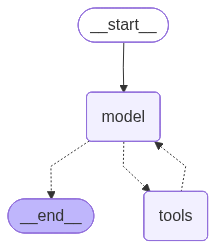

In [9]:
agent._agent

In [10]:
from src import Agent

agent = Agent(system_prompt="Ты эксперт по урбанистике. Используй инструменты для доступа к данным из OSM. Не придумывай информацию, основывайся только на результатах вызова инструментов.", tools=[query_osm], debug=True)

print(agent.invoke("""
Дан следующий адрес:
Тюмень, Московский тракт, 169
Не понимаю, могу ли я использовать данные из ОСМ по нему и в округе, либо их надо как-то восполнять.
"""))

[values] {'messages': [HumanMessage(content='\nДан следующий адрес:\nТюмень, Московский тракт, 169\nНе понимаю, могу ли я использовать данные из ОСМ по нему и в округе, либо их надо как-то восполнять.\n', additional_kwargs={}, response_metadata={}, id='f1b03b25-1b01-42ad-9184-ee88a978df3c')]}
[updates] {'model': {'messages': [AIMessage(content='Я могу помочь вам проанализировать доступность данных OpenStreetMap для этого адреса и его окружения. Давайте проверим, какие данные доступны в OSM для адреса "Тюмень, Московский тракт, 169" и его окрестностей.\n', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 107, 'prompt_tokens': 404, 'total_tokens': 511, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 320, 'cache_write_tokens': 0, 'video_tokens': 0}}, 'model_provider': 'o